# Compreendo os dados

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/data-science-regressao-linear/main/dados/precos_casas.csv')
df.head()

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
0,1042500,79.52,1,23.86,1.639,3.039
1,907500,117.24,0,35.17,1.538,10.910
2,1117500,85.47,1,25.64,1.275,11.791
3,700000,89.28,1,21.07,1.223,10.877
4,1250000,106.37,1,31.91,0.868,11.247


In [7]:
# Verificando a quantidade de dados
print(df.shape)

(1460, 6)


In [8]:
# Como estão meus dados? Temos dados nulos? Quais são os tipos de dados?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   valor                 1460 non-null   int64  
 1   area_primeiro_andar   1460 non-null   float64
 2   existe_segundo_andar  1460 non-null   int64  
 3   area_quintal          1460 non-null   float64
 4   dist_metro            1460 non-null   float64
 5   dist_parque           1460 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 68.6 KB


## Entendendo a relação dos dados

In [9]:
corr = df.corr().round(3)
corr

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
valor,1.000,0.606,0.138,0.614,-0.644,-0.071
area_primeiro_andar,0.606,1.000,-0.339,0.820,-0.369,-0.058
existe_segundo_andar,0.138,-0.339,1.000,-0.301,-0.191,-0.007
area_quintal,0.614,0.820,-0.301,1.000,-0.440,-0.058
dist_metro,-0.644,-0.369,-0.191,-0.440,1.000,0.089
dist_parque,-0.071,-0.058,-0.007,-0.058,0.089,1.000


In [10]:
# Correlaçaõ do preço de venda
corr['valor'].to_frame()

,valor
valor,1.000
area_primeiro_andar,0.606
existe_segundo_andar,0.138
area_quintal,0.614
dist_metro,-0.644
dist_parque,-0.071


## Visualizando uma Regressão Linear com uma variável independente

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

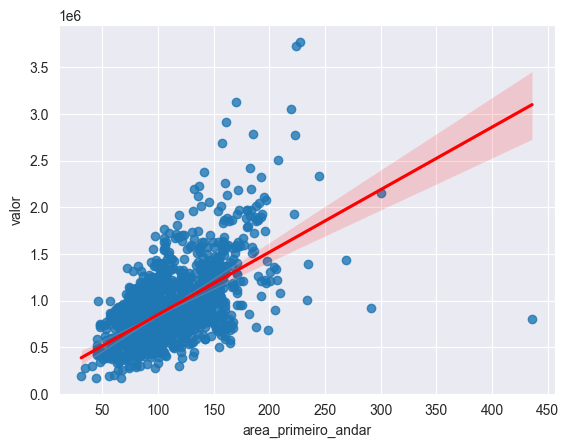

In [12]:
sns.set_style('darkgrid')
sns.regplot(x='area_primeiro_andar', y='valor', data=df, line_kws={'color': 'red'}, )
plt.show();

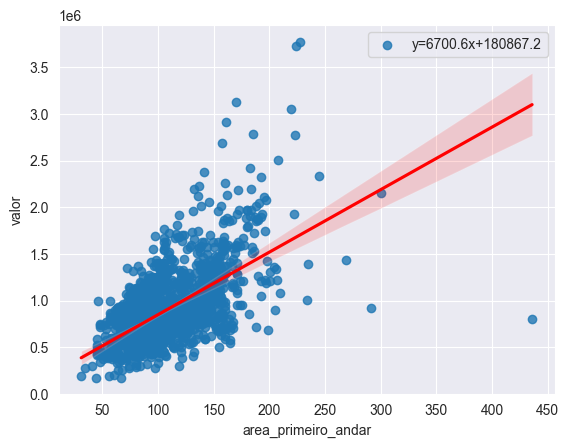

In [13]:
from scipy import stats
slope, intercept, rvalue, pvalue, stderr = stats.linregress(df['area_primeiro_andar'], df['valor'])

sns.regplot(x='area_primeiro_andar', y='valor', data=df, line_kws={'color':'red'}, label=f"y={slope:.1f}x+{intercept:.1f}").legend(loc="best")
plt.show()

# Neste caso o y é o coeficiente de regressão, onde indica que para cada 1m² que adiconamos ele sobe em R$6.700,60
# O intercepto que indica o valor da casa se a área fosse desconsiderada = R$180.867,20

# Análises Gráficas

## Visualizando o comportamento da variável dependente

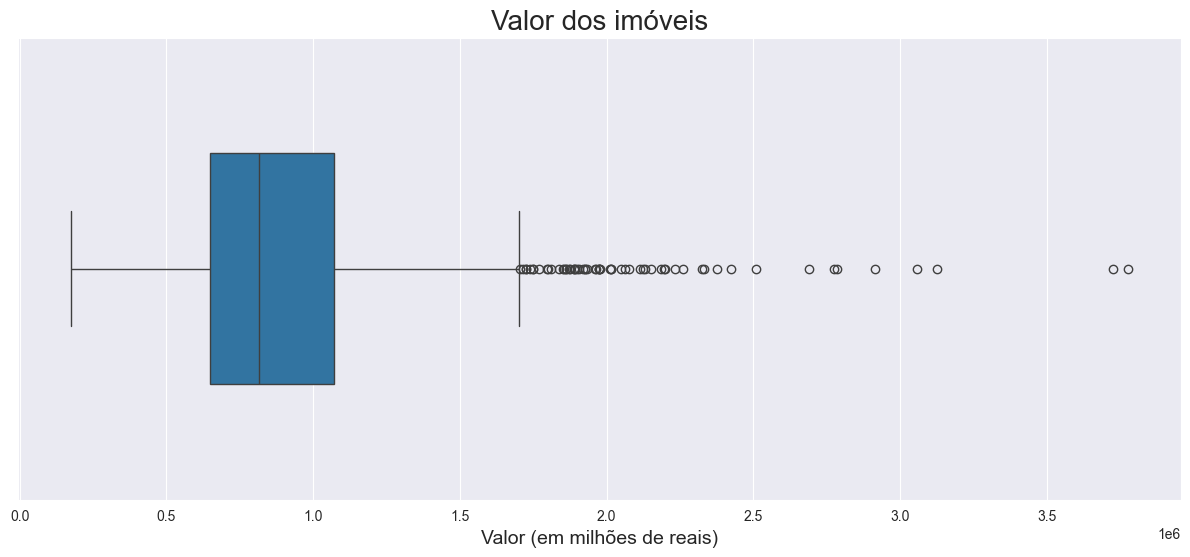

In [14]:
ax = sns.boxplot(x='valor', data=df, width=0.5)
ax.figure.set_size_inches(15, 6)
ax.set_title('Valor dos imóveis', fontsize=20)
ax.set_xlabel('Valor (em milhões de reais)', fontsize=14)

plt.show();

## Investigando a distribuição de frequências da variável dependente

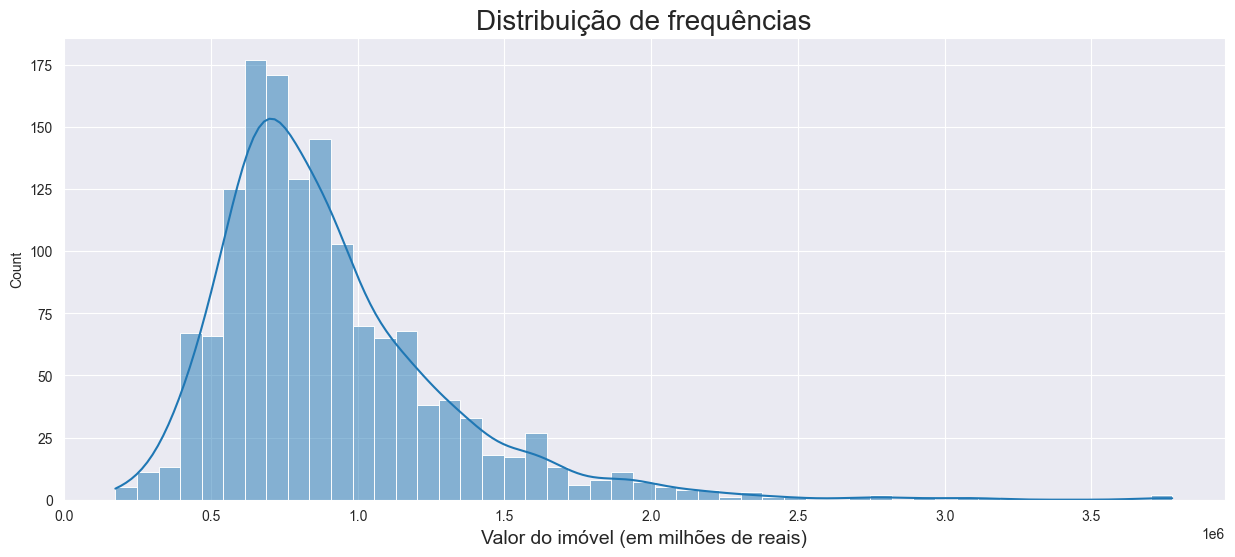

In [15]:
ax = sns.histplot(data=df, x='valor', kde=True)
ax.figure.set_size_inches(15, 6)
ax.set_title('Distribuição de frequências', fontsize=20)
ax.set_xlabel('Valor do imóvel (em milhões de reais)', fontsize=14)
plt.show();

## Analisando as variáveis indepedentes

In [16]:
df.columns

Index(['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal',
       'dist_metro', 'dist_parque'],
      dtype='object')

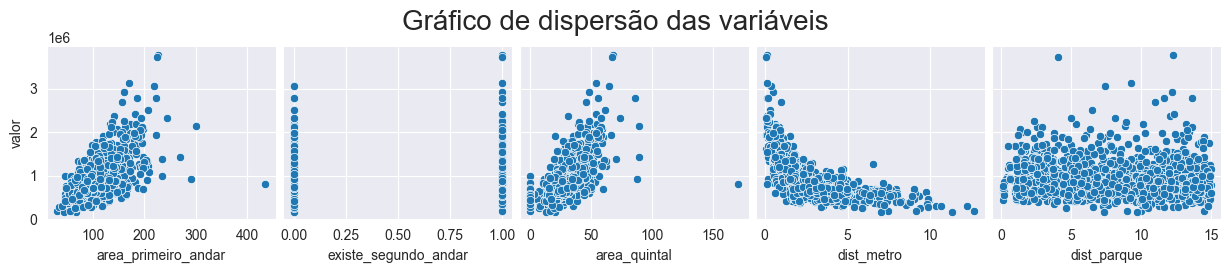

In [17]:
ax = sns.pairplot(data=df, y_vars='valor', x_vars=['area_primeiro_andar', 'existe_segundo_andar', 'area_quintal','dist_metro', 'dist_parque'])
ax.figure.suptitle('Gráfico de dispersão das variáveis', fontsize=20, y=1.05)
plt.show()

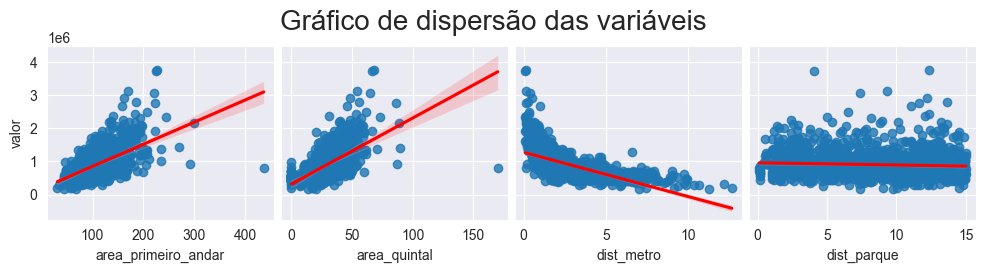

In [18]:
# Pairpot com reta de regressão
ax = sns.pairplot(data=df, y_vars='valor', x_vars=['area_primeiro_andar', 'area_quintal','dist_metro', 'dist_parque'], kind='reg', plot_kws={'line_kws': {'color': 'red'}})
ax.figure.suptitle('Gráfico de dispersão das variáveis', fontsize=20, y=1.05)
plt.show()

## Aplicando a transformação logarítmica

In [19]:
# Verificando se há 0 nas variáveis explicativas do nosso df
df.describe().round(2)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,904605.98,108.01,0.43,29.47,2.77,8.15
std,397212.51,35.92,0.50,12.23,1.91,4.20
min,174500.00,31.03,0.00,0.00,0.10,0.12
25%,649875.00,81.94,0.00,22.18,1.42,4.44
50%,815000.00,100.98,0.00,27.64,2.26,8.72
75%,1070000.00,129.25,1.00,36.18,3.89,11.63
max,3775000.00,435.90,1.00,170.29,12.65,15.00


In [20]:
import numpy as np 

df['log_valor'] = np.log(df['valor'])
df['log_area_primeiro_andar'] = np.log(df['area_primeiro_andar'])
df['log_area_quintal'] = np.log1p(df['area_quintal'])
df['log_dist_metro'] = np.log(df['dist_metro'])
df['log_dist_parque'] = np.log(df['dist_parque'])

In [21]:
df.head(3)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque,log_valor,log_area_primeiro_andar,log_area_quintal,log_dist_metro,log_dist_parque
0,1042500,79.52,1,23.86,1.639,3.039,13.857132,4.376009,3.213260,0.494086,1.111529
1,907500,117.24,0,35.17,1.538,10.910,13.718449,4.764223,3.588230,0.430483,2.389680
2,1117500,85.47,1,25.64,1.275,11.791,13.926605,4.448165,3.282414,0.242946,2.467337


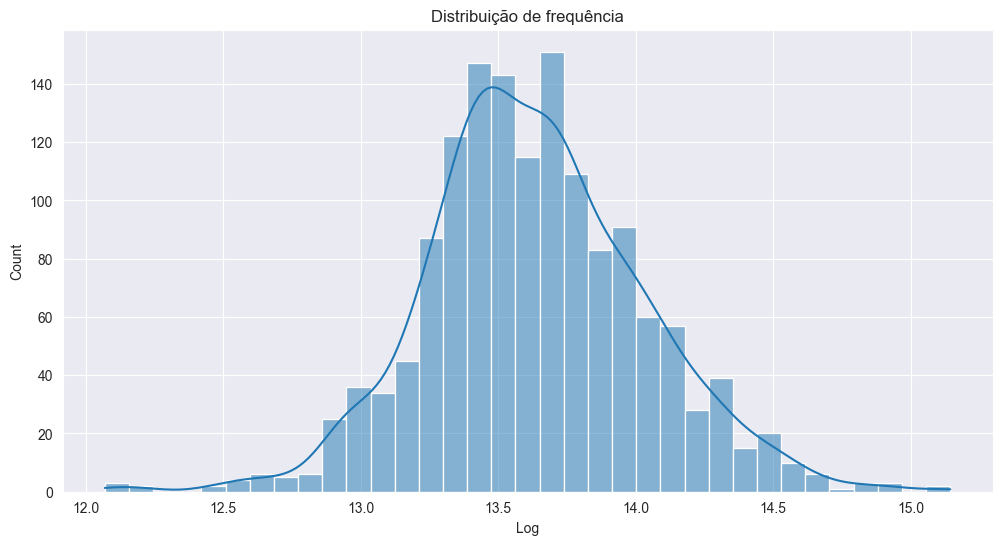

In [22]:
ax = sns.histplot(data=df, x='log_valor', kde=True)
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de frequência', fontsize=12)
ax.set_xlabel('Log')
plt.show();

# Verificando a relação linear

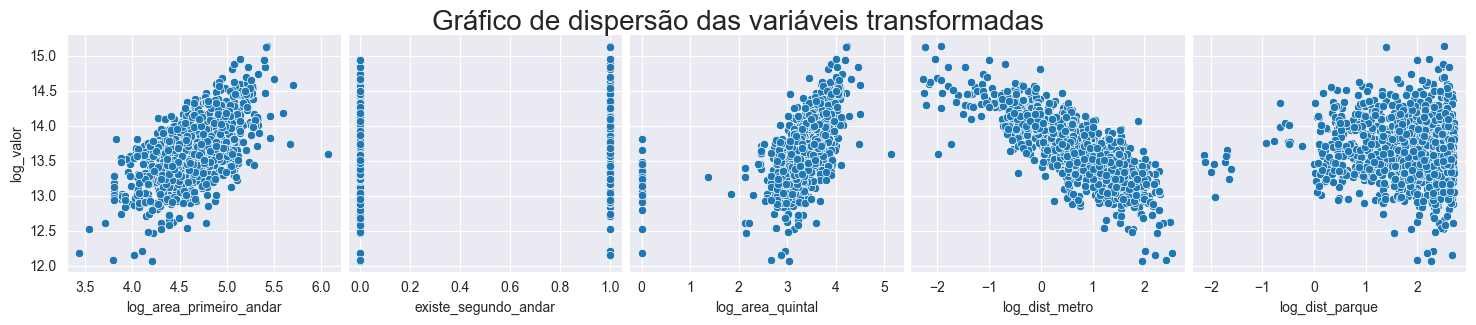

In [27]:
ax = sns.pairplot(data=df, y_vars='log_valor', x_vars=['log_area_primeiro_andar', 'existe_segundo_andar', 
                                                       'log_area_quintal','log_dist_metro', 
                                                       'log_dist_parque'],height=3)
ax.figure.suptitle('Gráfico de dispersão das variáveis transformadas', fontsize=20, y=1.05)
plt.show()

# Regressão Linear Múltipla